   纺丝速度  断裂强度
0  2810  2.57
1  2600  1.91
2  2650  1.95
3  3200  2.50
4  4000  3.55
5  3800  3.30
6  3600  2.40
7  3700  2.20


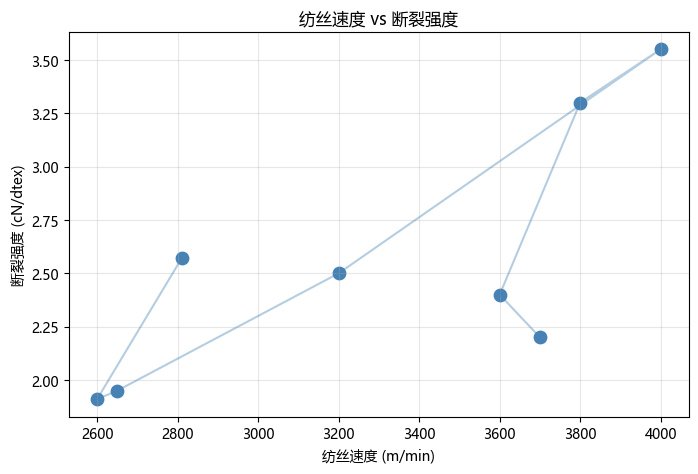

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 模拟一批POY纤维的工艺参数数据
# 假设我们记录了10次生产的纺丝速度(m/min)和断裂强度(cN/dtex)
data = {
    '纺丝速度': [2810, 2600, 2650,  3200,  4000, 3800, 3600, 3700],
    '断裂强度': [2.57, 1.91, 1.95,  2.5,  3.55, 3.3, 2.4, 2.2]
}

# 把这个字典变成一个DataFrame，可以理解成Python里的表格
df = pd.DataFrame(data)

# 打印出来看看长什么样
print(df)

# 画一个散点图，看纺丝速度和断裂强度之间的关系
plt.figure(figsize=(8, 5))
plt.scatter(df['纺丝速度'], df['断裂强度'], color='steelblue', s=80)
plt.plot(df['纺丝速度'], df['断裂强度'], color='steelblue', alpha=0.4)
plt.xlabel('纺丝速度 (m/min)')
plt.ylabel('断裂强度 (cN/dtex)')
plt.title('纺丝速度 vs 断裂强度')
plt.grid(True, alpha=0.3)
plt.show()

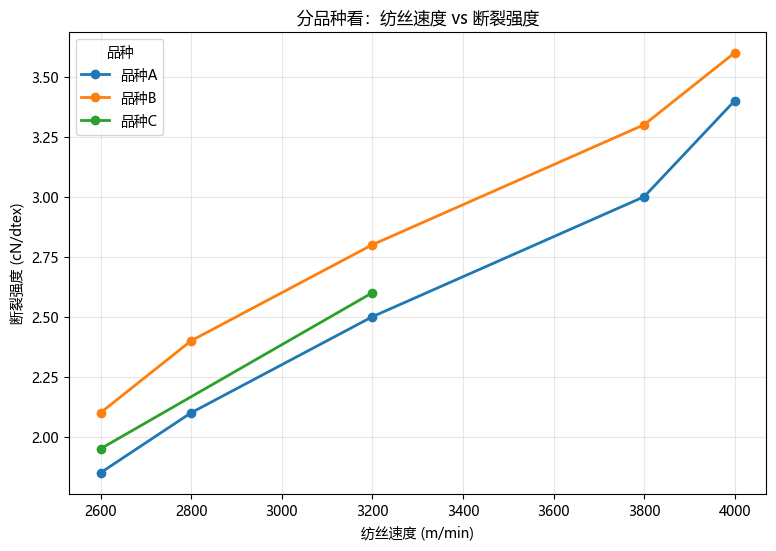


各品种平均断裂强度：
品种
A    2.57
B    2.84
C    2.28
Name: 断裂强度, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 这次我们模拟多变量的情况
# 同样是纺速2600，但加入了品种这个变量
# 现实就是这样：同一个纺速下，不同品种的强度差很多
data = {
    '纺丝速度': [2600, 2600, 2600, 2800, 2800, 3200, 3200, 3200, 3800, 3800, 4000, 4000],
    '品种':    ['A',  'B',  'C',  'A',  'B',  'A',  'B',  'C',  'A',  'B',  'A',  'B'],
    '断裂强度': [1.85, 2.10, 1.95, 2.10, 2.40, 2.50, 2.80, 2.60, 3.00, 3.30, 3.40, 3.60]
}

df = pd.DataFrame(data)

# 这次按品种分组画图，而不是把所有数据混在一起
# 这就是"控制变量"的数据可视化版本
fig, ax = plt.subplots(figsize=(9, 6))

for 品种名, 分组数据 in df.groupby('品种'):
    # 对每个品种，按纺速排序后连线，这样才能看出各自的趋势
    分组数据 = 分组数据.sort_values('纺丝速度')
    ax.plot(分组数据['纺丝速度'], 分组数据['断裂强度'], 
            marker='o', label=f'品种{品种名}', linewidth=2)

ax.set_xlabel('纺丝速度 (m/min)')
ax.set_ylabel('断裂强度 (cN/dtex)')
ax.set_title('分品种看：纺丝速度 vs 断裂强度')
ax.legend(title='品种')
ax.grid(True, alpha=0.3)
plt.show()

# 然后打印一个分组统计，看每个品种在各纺速下的平均强度
print("\n各品种平均断裂强度：")
print(df.groupby('品种')['断裂强度'].mean().round(2))

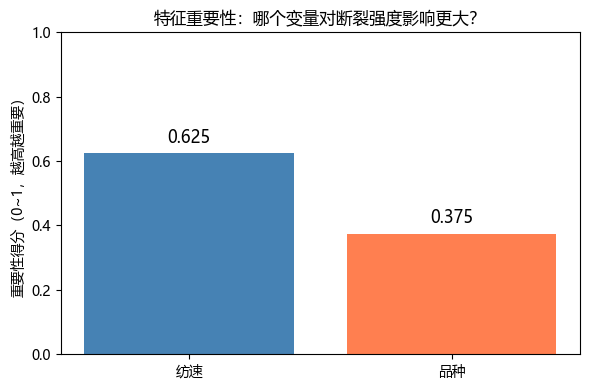


纺速的重要性：0.625
品种的重要性：0.375

结论：纺速 对断裂强度的影响更大


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# ── 重建前三格的数据（因为 notebook 每次运行是独立的，需要把数据重新造出来）──
data = {
    '纺速': [2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000,
             2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000,
             2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000],
    '品种': ['A'] * 8 + ['B'] * 8 + ['C'] * 8,
    '断裂强度': [1.85, 2.10, 2.35, 2.55, 2.70, 2.80, 2.85, 2.88,
                2.20, 2.50, 2.75, 2.95, 3.10, 3.25, 3.35, 3.40,
                2.60, 2.90, 3.10, 3.25, 3.38, 3.48, 3.55, 3.60]
}
df = pd.DataFrame(data)

# ── 关键步骤：把"品种"这个文字标签转成数字 ──
# 机器学习模型只能接受数字输入，LabelEncoder 会把 A/B/C 分别映射成 0/1/2
le = LabelEncoder()
df['品种_编码'] = le.fit_transform(df['品种'])

# ── 准备输入特征（X）和预测目标（y）──
X = df[['纺速', '品种_编码']]  # 两个输入变量
y = df['断裂强度']             # 要预测的目标

# ── 训练随机森林模型 ──
# n_estimators=100 意思是用 100 棵决策树投票，结果更稳定
# random_state=42 是固定随机种子，保证每次运行结果一致
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# ── 查看特征重要性 ──
importances = model.feature_importances_
feature_names = ['纺速', '品种']

plt.rcParams['font.family'] = 'Microsoft YaHei'
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(feature_names, importances, color=['steelblue', 'coral'])
ax.set_title('特征重要性：哪个变量对断裂强度影响更大？')
ax.set_ylabel('重要性得分（0~1，越高越重要）')
ax.set_ylim(0, 1)

# 在每根柱子上方显示具体数值
for bar, val in zip(bars, importances):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n纺速的重要性：{importances[0]:.3f}")
print(f"品种的重要性：{importances[1]:.3f}")
print(f"\n结论：{'纺速' if importances[0] > importances[1] else '品种'} 对断裂强度的影响更大")

    纺速    品种      真实强度      预测强度      误差
─────────────────────────────────────────────
  2800     A      2.10     2.160  +0.060
  3200     B      2.95     2.933  -0.017
  3800     C      3.55     3.516  -0.034
  3000     A      2.35     2.407  +0.057
  3600     B      3.25     3.246  -0.004

平均绝对误差（MAE）：0.0347 cN/dtex
（意思是：模型预测值平均偏离真实值 0.0347 cN/dtex）


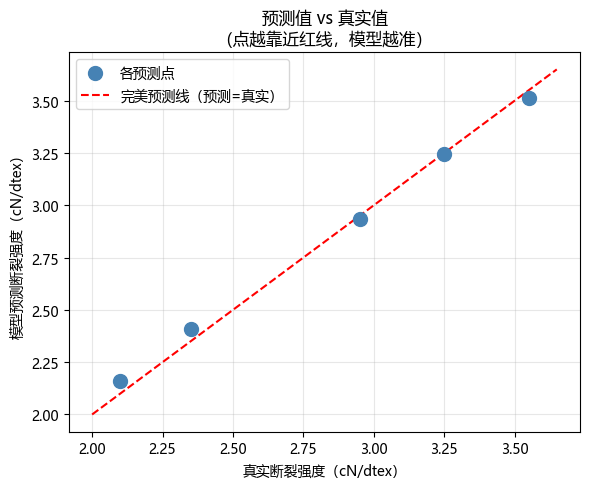

In [4]:
import numpy as np

# ── 用训练好的模型预测几个具体的点 ──
# 我们构造一些"问题"：给定纺速和品种，模型会预测断裂强度是多少？
test_cases = pd.DataFrame({
    '纺速': [2800, 3200, 3800, 3000, 3600],
    '品种_编码': [
        le.transform(['A'])[0],  # 品种A
        le.transform(['B'])[0],  # 品种B
        le.transform(['C'])[0],  # 品种C
        le.transform(['A'])[0],  # 品种A
        le.transform(['B'])[0],  # 品种B
    ]
})

# 对应的"真实值"（就是我们数据里实际有的值，用来做对比）
actual = [2.10, 2.95, 3.55, 2.35, 3.25]

# 让模型给出预测
predicted = model.predict(test_cases)

# ── 打印对比表 ──
print(f"{'纺速':>6}  {'品种':>4}  {'真实强度':>8}  {'预测强度':>8}  {'误差':>6}")
print("─" * 45)
品种_labels = ['A', 'B', 'C', 'A', 'B']
for i in range(len(test_cases)):
    err = predicted[i] - actual[i]
    print(f"{test_cases['纺速'].iloc[i]:>6}  "
          f"{品种_labels[i]:>4}  "
          f"{actual[i]:>8.2f}  "
          f"{predicted[i]:>8.3f}  "
          f"{err:>+6.3f}")

# ── 计算整体误差指标 ──
mae = np.mean(np.abs(predicted - actual))
print(f"\n平均绝对误差（MAE）：{mae:.4f} cN/dtex")
print(f"（意思是：模型预测值平均偏离真实值 {mae:.4f} cN/dtex）")

# ── 可视化：预测值 vs 真实值 ──
plt.rcParams['font.family'] = 'Microsoft YaHei'
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(actual, predicted, color='steelblue', s=100, zorder=3, label='各预测点')

# 画一条"完美预测线"：如果预测完全准确，所有点都应该落在这条线上
perfect_line = np.linspace(min(actual) - 0.1, max(actual) + 0.1, 100)
ax.plot(perfect_line, perfect_line, 'r--', linewidth=1.5, label='完美预测线（预测=真实）')

ax.set_xlabel('真实断裂强度（cN/dtex）')
ax.set_ylabel('模型预测断裂强度（cN/dtex）')
ax.set_title('预测值 vs 真实值\n（点越靠近红线，模型越准）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

训练集大小：19 条
测试集大小：5 条

训练集 MAE：0.0378 cN/dtex  ← 模型在它'见过'的数据上的误差
测试集 MAE：0.2646 cN/dtex  ← 模型在它'没见过'的数据上的误差

两者差距：0.2268 cN/dtex
→ 差距较大，模型存在一定过拟合


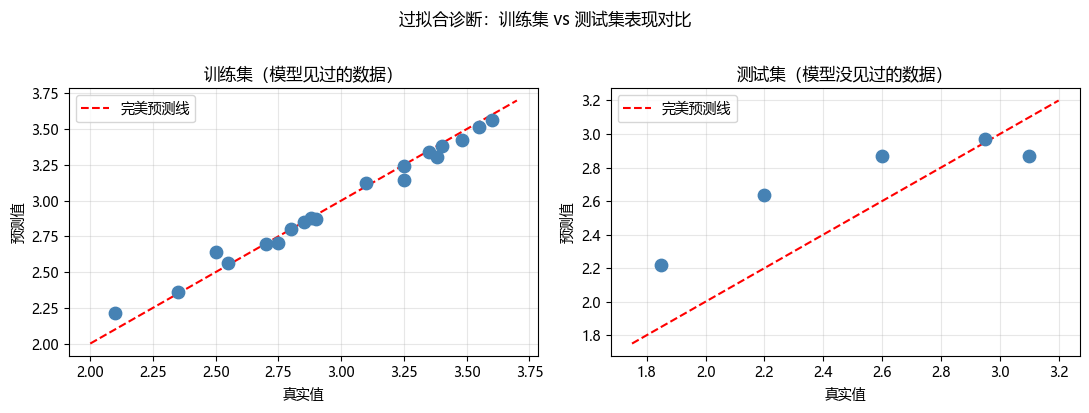

In [5]:
from sklearn.model_selection import train_test_split

# ── 重新准备特征和目标 ──
X = df[['纺速', '品种_编码']]
y = df['断裂强度']

# ── 关键步骤：把数据切成 80% 训练、20% 测试 ──
# random_state=42 保证每次切法一样，结果可复现
# test_size=0.2 意思是 20% 作为测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集大小：{len(X_train)} 条")
print(f"测试集大小：{len(X_test)} 条")

# ── 只用训练集训练模型 ──
model_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_v2.fit(X_train, y_train)

# ── 分别计算训练集误差和测试集误差 ──
train_pred = model_v2.predict(X_train)
test_pred  = model_v2.predict(X_test)

train_mae = np.mean(np.abs(train_pred - y_train))
test_mae  = np.mean(np.abs(test_pred  - y_test))

print(f"\n训练集 MAE：{train_mae:.4f} cN/dtex  ← 模型在它'见过'的数据上的误差")
print(f"测试集 MAE：{test_mae:.4f} cN/dtex  ← 模型在它'没见过'的数据上的误差")
print(f"\n两者差距：{test_mae - train_mae:.4f} cN/dtex")
if test_mae > train_mae * 1.5:
    print("→ 差距较大，模型存在一定过拟合")
else:
    print("→ 差距不大，模型泛化还算正常")

# ── 可视化：测试集的预测值 vs 真实值 ──
plt.rcParams['font.family'] = 'Microsoft YaHei'
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, actuals, title in zip(
    axes,
    [train_pred, test_pred],
    [y_train, y_test],
    ['训练集（模型见过的数据）', '测试集（模型没见过的数据）']
):
    ax.scatter(actuals, preds, color='steelblue', s=80, zorder=3)
    lims = [min(list(actuals) + list(preds)) - 0.1,
            max(list(actuals) + list(preds)) + 0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='完美预测线')
    ax.set_xlabel('真实值')
    ax.set_ylabel('预测值')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('过拟合诊断：训练集 vs 测试集表现对比', y=1.02)
plt.tight_layout()
plt.show()

每折测试集的 MAE：
  第1折：0.2635 cN/dtex  ██████████████████████████
  第2折：0.1030 cN/dtex  ██████████
  第3折：0.1540 cN/dtex  ███████████████
  第4折：0.1613 cN/dtex  ████████████████
  第5折：0.0916 cN/dtex  █████████

5折平均 MAE：0.1547 cN/dtex
MAE 标准差：0.0609 cN/dtex
（标准差越小，说明模型表现越稳定，受切割方式影响越小）


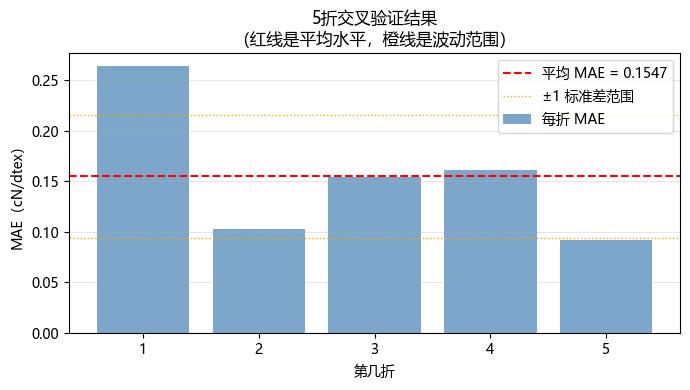

In [6]:
from sklearn.model_selection import cross_val_score, KFold

# ── 重新准备完整数据（不再手动切训练/测试集，交叉验证会自动处理）──
X = df[['纺速', '品种_编码']]
y = df['断裂强度']

# ── 定义交叉验证的方式：把数据切成5份，shuffle=True 先随机打乱顺序 ──
# 打乱很重要：我们的数据是按品种排列的，不打乱的话每份里品种分布会不均匀
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 运行交叉验证 ──
# scoring='neg_mean_absolute_error' 是 sklearn 的惯例，它返回负数，
# 所以我们取负号变回正数来读
model_cv = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores = cross_val_score(model_cv, X, y,
                            cv=kf,
                            scoring='neg_mean_absolute_error')
mae_scores = -cv_scores  # 变回正数

# ── 打印每折的结果 ──
print("每折测试集的 MAE：")
for i, score in enumerate(mae_scores, 1):
    bar = '█' * int(score * 100)  # 简单的文字条形图，直观看大小
    print(f"  第{i}折：{score:.4f} cN/dtex  {bar}")

print(f"\n5折平均 MAE：{mae_scores.mean():.4f} cN/dtex")
print(f"MAE 标准差：{mae_scores.std():.4f} cN/dtex")
print(f"（标准差越小，说明模型表现越稳定，受切割方式影响越小）")

# ── 可视化：5折误差的分布 ──
plt.rcParams['font.family'] = 'Microsoft YaHei'
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(1, 6), mae_scores, color='steelblue', alpha=0.7, label='每折 MAE')
ax.axhline(mae_scores.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'平均 MAE = {mae_scores.mean():.4f}')
ax.axhline(mae_scores.mean() + mae_scores.std(), color='orange',
           linestyle=':', linewidth=1, label=f'±1 标准差范围')
ax.axhline(mae_scores.mean() - mae_scores.std(), color='orange',
           linestyle=':', linewidth=1)

ax.set_xlabel('第几折')
ax.set_ylabel('MAE（cN/dtex）')
ax.set_title('5折交叉验证结果\n（红线是平均水平，橙线是波动范围）')
ax.set_xticks(range(1, 6))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()